# Banking Fraud Detection and Risk Analytics — EDA

Dataset: [deepeshkansotia/banking-fraud-detection-and-risk-analytics-dataset](https://www.kaggle.com/datasets/deepeshkansotia/banking-fraud-detection-and-risk-analytics-dataset) — CSV **`banking_transactions.csv`**.

Each row is a **synthetic banking transaction** described by amount, channel, authentication mode, device and session risk proxies, velocity-style scores, geospatial separation, and binary risk flags—the label is **`fraud_flag`**.


In [1]:
!pip install nicaviz;

In [2]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")


def _distplot_compat(a, ax=None, **kwargs):
    """Seaborn ≥0.12 removed `sns.distplot`; nicaviz still calls it internally."""
    kde_kws = kwargs.pop("kde_kws", {}) or {}
    if ax is None:
        ax = plt.gca()
    sns.histplot(a, ax=ax, kde=True, stat="density", kde_kws=kde_kws, **kwargs)
    return ax


if not hasattr(sns, "distplot"):
    sns.distplot = _distplot_compat

import nicaviz  # noqa: F401 — registers `DataFrame.nica` accessor


## Load data

On Kaggle, files live under **`/kaggle/input/…`**. On macOS, **`kagglehub`** pulls the archive into its cache unless you mirror the CSV at **`eda/data/banking_transactions.csv`**.


In [3]:
DATA_SLUG = "deepeshkansotia/banking-fraud-detection-and-risk-analytics-dataset"
CSV_NAME = "banking_transactions.csv"


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        named = sorted(kaggle_root.rglob(CSV_NAME), key=lambda p: p.stat().st_size, reverse=True)
        if named:
            return named[0]
        any_csv = list(kaggle_root.rglob("*.csv"))
        if any_csv:
            return max(any_csv, key=lambda p: p.stat().st_size)
        raise FileNotFoundError(f"No CSV under {kaggle_root}")

    local = Path("data") / CSV_NAME
    if local.exists():
        return local.resolve()

    root = Path(kagglehub.dataset_download(DATA_SLUG))
    nested = list(root.glob(f"**/{CSV_NAME}"))
    if nested:
        return nested[0]

    csvs = list(root.rglob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV under kagglehub path {root}")
    return max(csvs, key=lambda p: p.stat().st_size)


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
print(df.shape[0], "rows ×", df.shape[1], "cols")


CSV: /kaggle/input/datasets/deepeshkansotia/banking-fraud-detection-and-risk-analytics-dataset/banking_transactions.csv
10000 rows × 20 cols


## First look

Random sample, dtypes, and numeric **`describe`** to ground every later plot.


In [4]:
display(df.sample(5, random_state=42))
display(df.dtypes.to_frame("dtype"))
display(df.describe().T)

CAT_COLS = ["payment_channel", "authentication_type"]
ID_COLS = ["transaction_id"]
NUM_COLS = [
    c
    for c in df.columns
    if c not in ID_COLS + CAT_COLS and c != "fraud_flag"
]
VALUE_VARS = NUM_COLS

corr_df = df.drop(columns=ID_COLS).copy()
corr_df["fraud_flag"] = corr_df["fraud_flag"].astype(np.int8)
CORR_COLS = [c for c in corr_df.columns if c not in CAT_COLS]


,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
6252,1006253,10017.15,3,95.0,77,0.34,3429,12,20,460770.82,90,347,37,95.0,POS Terminal,Biometric,1,0,1,False
4684,1004685,21849.28,6,29.0,2,0.26,3905,23,15,161508.10,81,3559,110,40.3,Mobile App,OTP,1,1,0,False
1731,1001732,15066.16,5,29.5,15,0.48,717,14,22,181946.40,113,10298,44,77.5,POS Terminal,OTP,0,0,1,False
4742,1004743,22485.40,8,90.4,43,0.78,3140,9,12,475010.56,49,10065,18,29.5,Mobile App,Biometric,1,0,1,True
4521,1004522,13962.60,5,49.9,64,0.05,371,18,5,353663.18,1,10279,42,88.3,Mobile App,OTP,1,0,1,False


,dtype
transaction_id,int64
transaction_amount,float64
login_attempts,int64
device_risk_score,float64
transfer_frequency,int64
anomaly_score,float64
account_age_days,int64
transaction_time_hour,int64
failed_transactions_last_30d,int64
avg_monthly_balance,float64


,count,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,1.005000e+06,2886.895680,1000001.00,1002500.750,1005000.500,1.007500e+06,1010000.00
transaction_amount,10000.0,1.241275e+04,7200.700863,6.27,6174.025,12322.965,1.861965e+04,24997.52
login_attempts,10000.0,6.438900e+00,3.453558,1.00,3.000,6.000,9.000000e+00,12.00
device_risk_score,10000.0,5.025719e+01,29.414463,0.00,25.100,50.200,7.550000e+01,100.00
transfer_frequency,10000.0,3.964840e+01,23.419868,0.00,19.000,40.000,6.000000e+01,80.00
anomaly_score,10000.0,3.489160e-01,0.236890,0.01,0.170,0.310,4.800000e-01,0.99
account_age_days,10000.0,2.510241e+03,1436.335019,6.00,1271.750,2511.000,3.746250e+03,5000.00
transaction_time_hour,10000.0,1.155360e+01,6.962254,0.00,6.000,11.000,1.800000e+01,23.00
failed_transactions_last_30d,10000.0,1.243780e+01,7.532875,0.00,6.000,13.000,1.900000e+01,25.00
avg_monthly_balance,10000.0,2.493675e+05,144580.006647,104.16,122291.355,249799.800,3.731468e+05,499968.25


### Categorical snapshot (`nica.categorical_describe`)

**`payment_channel`** and **`authentication_type`** set the operational context for the later heatmaps and pivot slices.


In [5]:
display(df[CAT_COLS].nica.categorical_describe())


Dataframe Dimension: 10000 Rows, 2 Columns


,Unique,Missing,dtype,ValCount 1,Occ,ValCount 2,Occ,ValCount 3,Occ,ValCount 4,Occ,ValCount 5,Occ
Column,,,,,,,,,,,,,
payment_channel,4,0,object,Mobile App,4804,Web Banking,3247,POS Terminal,1172,ATM,777,NaN,NaN
authentication_type,4,0,object,OTP,4214,Two-Factor Authentication,2384,Password Only,1817,Biometric,1585,NaN,NaN


## Univariate analysis

- **Categorical:** frequency bars via **`mass_plot` / `countplot`**.
- **Continuous / scores:** `catplot(kind="box")` sweeps across all numeric risk traits with **`fraud_flag`** hue, then a second sweep with **`payment_channel`** hue—`sharey=False` keeps heterogeneous units legible in one grid, matching the Costa Rica notebook’s full-distribution pass.


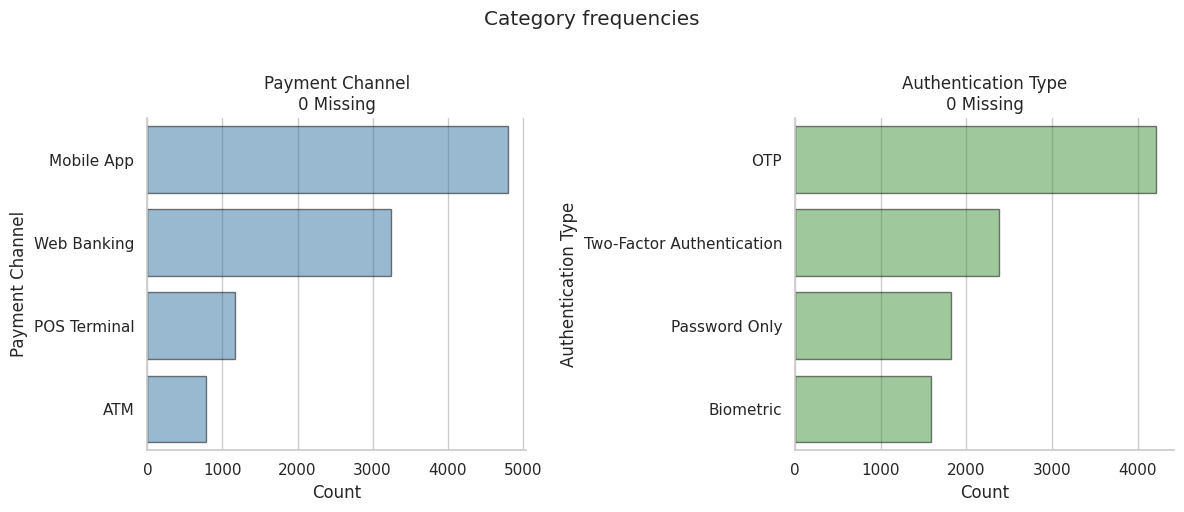

In [6]:
fig = df.nica.mass_plot(CAT_COLS, "countplot", columns=2, figsize=(12, 5))
fig.suptitle("Category frequencies", y=1.02)
plt.tight_layout()
plt.show()


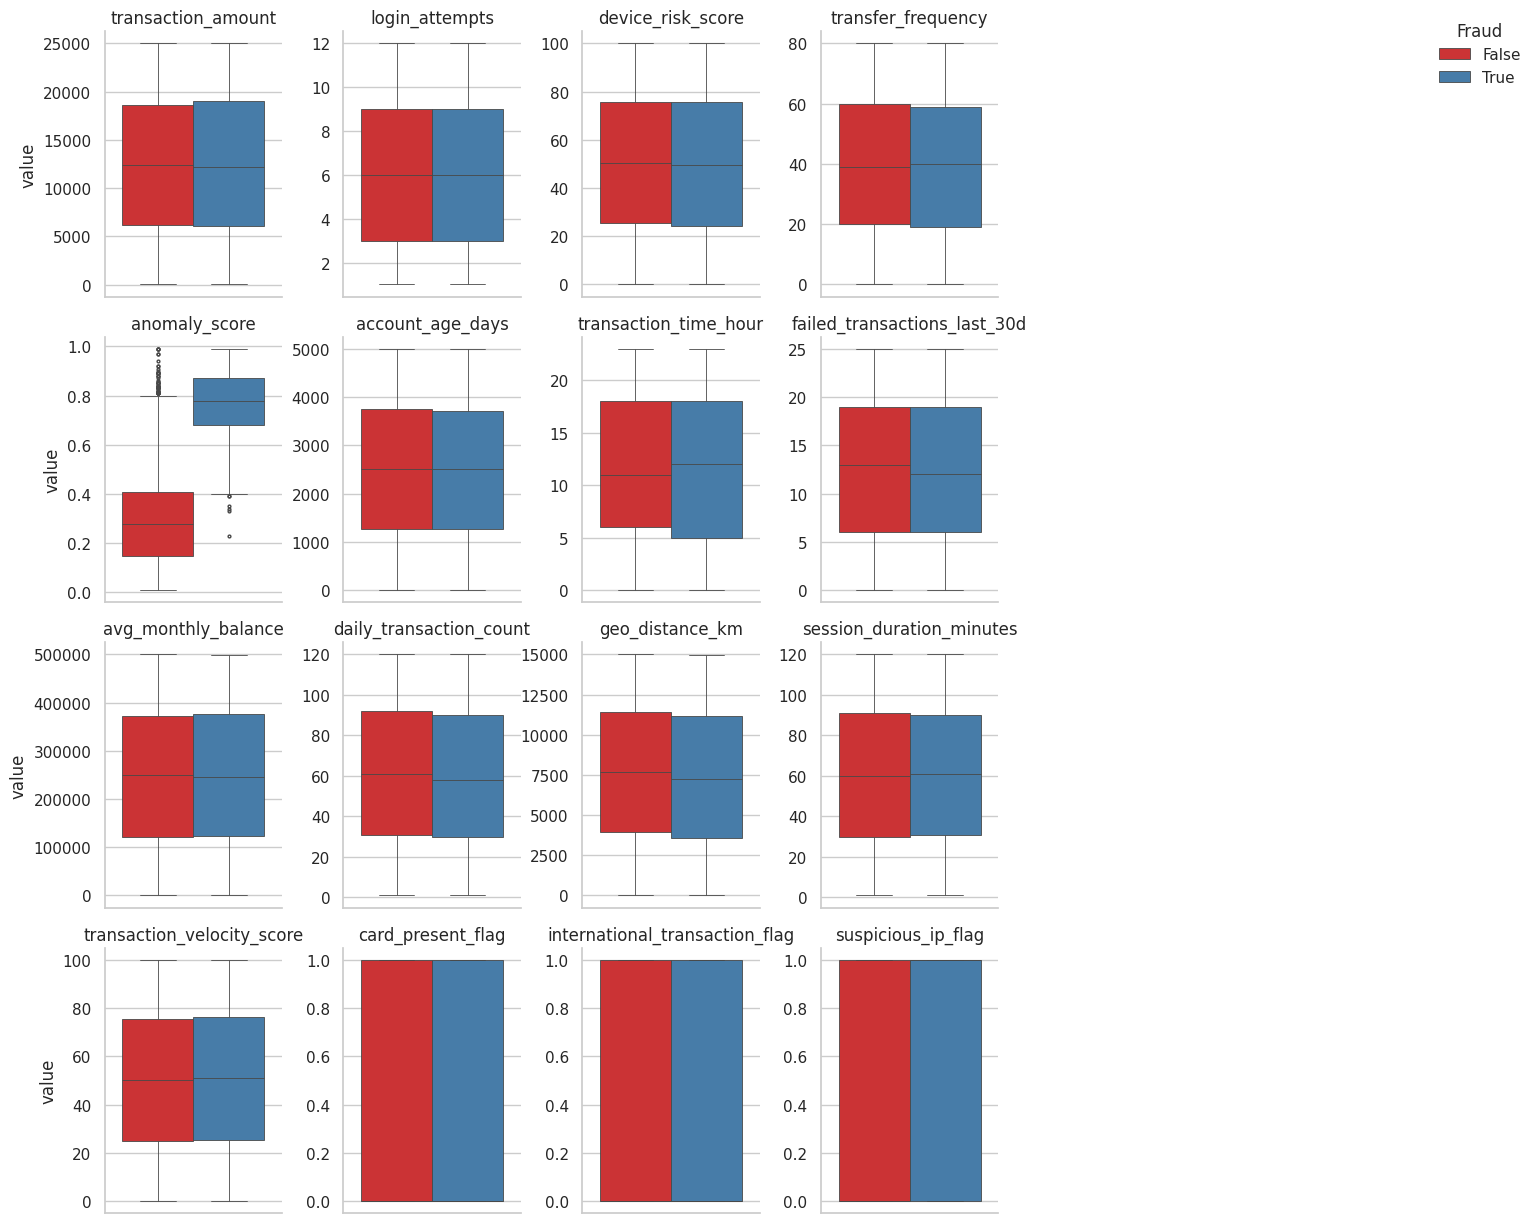

In [7]:
long_f = df.melt(
    id_vars=["fraud_flag"],
    value_vars=VALUE_VARS,
    var_name="variable",
    value_name="value",
)

g_f = sns.catplot(
    data=long_f,
    y="value",
    col="variable",
    hue="fraud_flag",
    kind="box",
    col_wrap=4,
    sharey=False,
    height=3.1,
    aspect=1.05,
    linewidth=0.6,
    fliersize=2,
    dodge=True,
    palette="Set1",
)
g_f.set_axis_labels("", "value")
g_f.set_titles("{col_name}")
if g_f._legend is not None:
    g_f._legend.set_title("Fraud")
    g_f._legend.set_bbox_to_anchor((1.02, 0.98))
    g_f._legend.set_loc("upper left")
g_f.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()


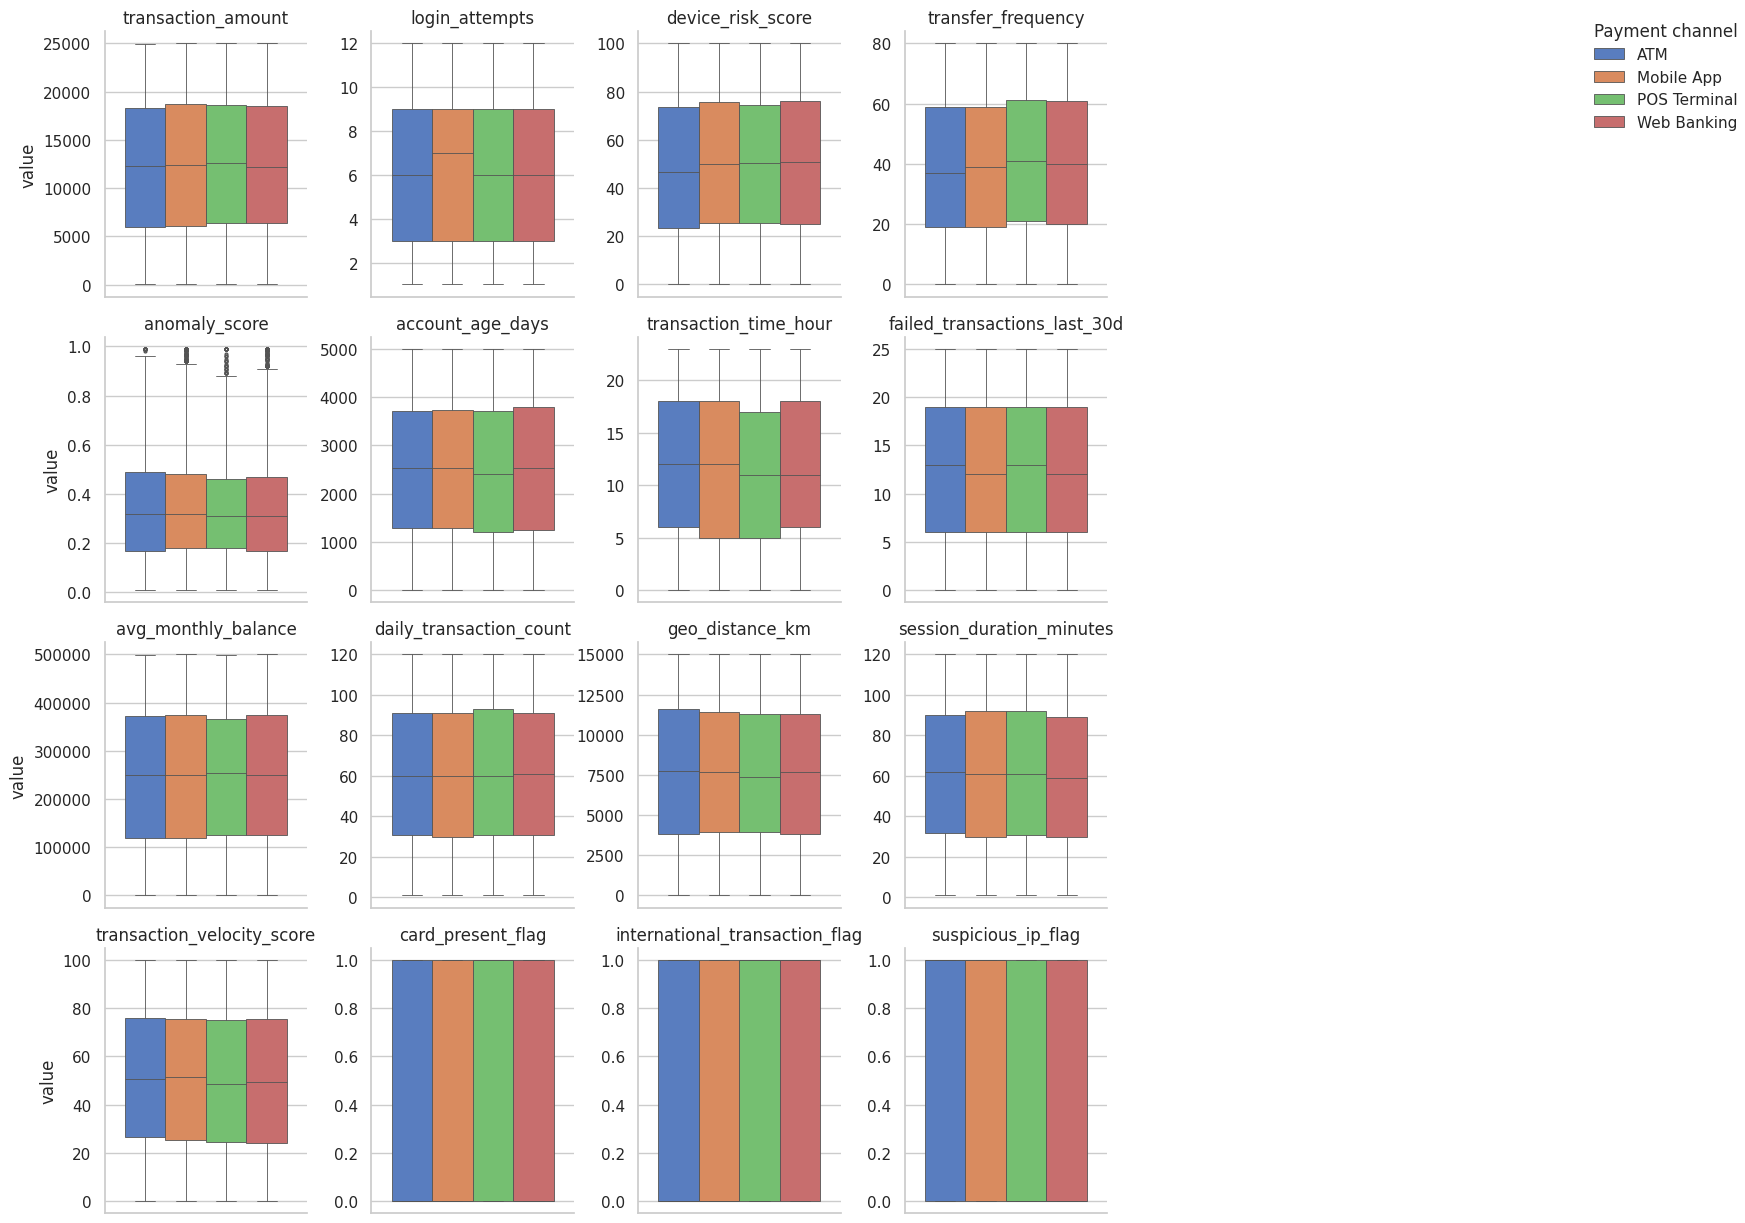

In [8]:
long_ch = df.melt(
    id_vars=["payment_channel"],
    value_vars=VALUE_VARS,
    var_name="variable",
    value_name="value",
)

hue_order_ch = sorted(long_ch["payment_channel"].dropna().unique())
g_ch = sns.catplot(
    data=long_ch,
    y="value",
    col="variable",
    hue="payment_channel",
    hue_order=hue_order_ch,
    kind="box",
    col_wrap=4,
    sharey=False,
    height=3.1,
    aspect=1.12,
    linewidth=0.6,
    fliersize=2,
    dodge=True,
    palette="muted",
)
g_ch.set_axis_labels("", "value")
g_ch.set_titles("{col_name}")
if g_ch._legend is not None:
    g_ch._legend.set_title("Payment channel")
    g_ch._legend.set_bbox_to_anchor((1.02, 0.98))
    g_ch._legend.set_loc("upper left")
g_ch.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()


### Univariate reflection

- **Class balance:** fraud is the minority outcome, so raw counts and box-**medians** for the **True** slice should be read beside **row-normalized** share tables.
- **Channels and auth modes:** volume concentrates in **mobile** and **OTP**, which can compress apparent fraud rates unless we normalize within each stratum.
- **Risk scores and velocity fields:** long tails on amount, anomaly, or velocity scores would motivate robust models later; here we stay descriptive.


## Multivariate analysis

1. **Correlation matrix** — how numeric risk traits co-move, with **`fraud_flag`** coded as 0/1.
2. **`rank_correlations_plots`** — strongest polynomial-tracked pairs (same spirit as Costa Rica).
3. **`lmplot`** — amount vs anomaly score with **`fraud_flag`** hue; legend anchored to the right of the facet.
4. **Two-way categoricals** — normalized **`crosstab`** heatmaps for channel × auth and channel × label.
5. **`pivot_plots`** — mean **`fraud_flag`** by **payment_channel × authentication_type**.


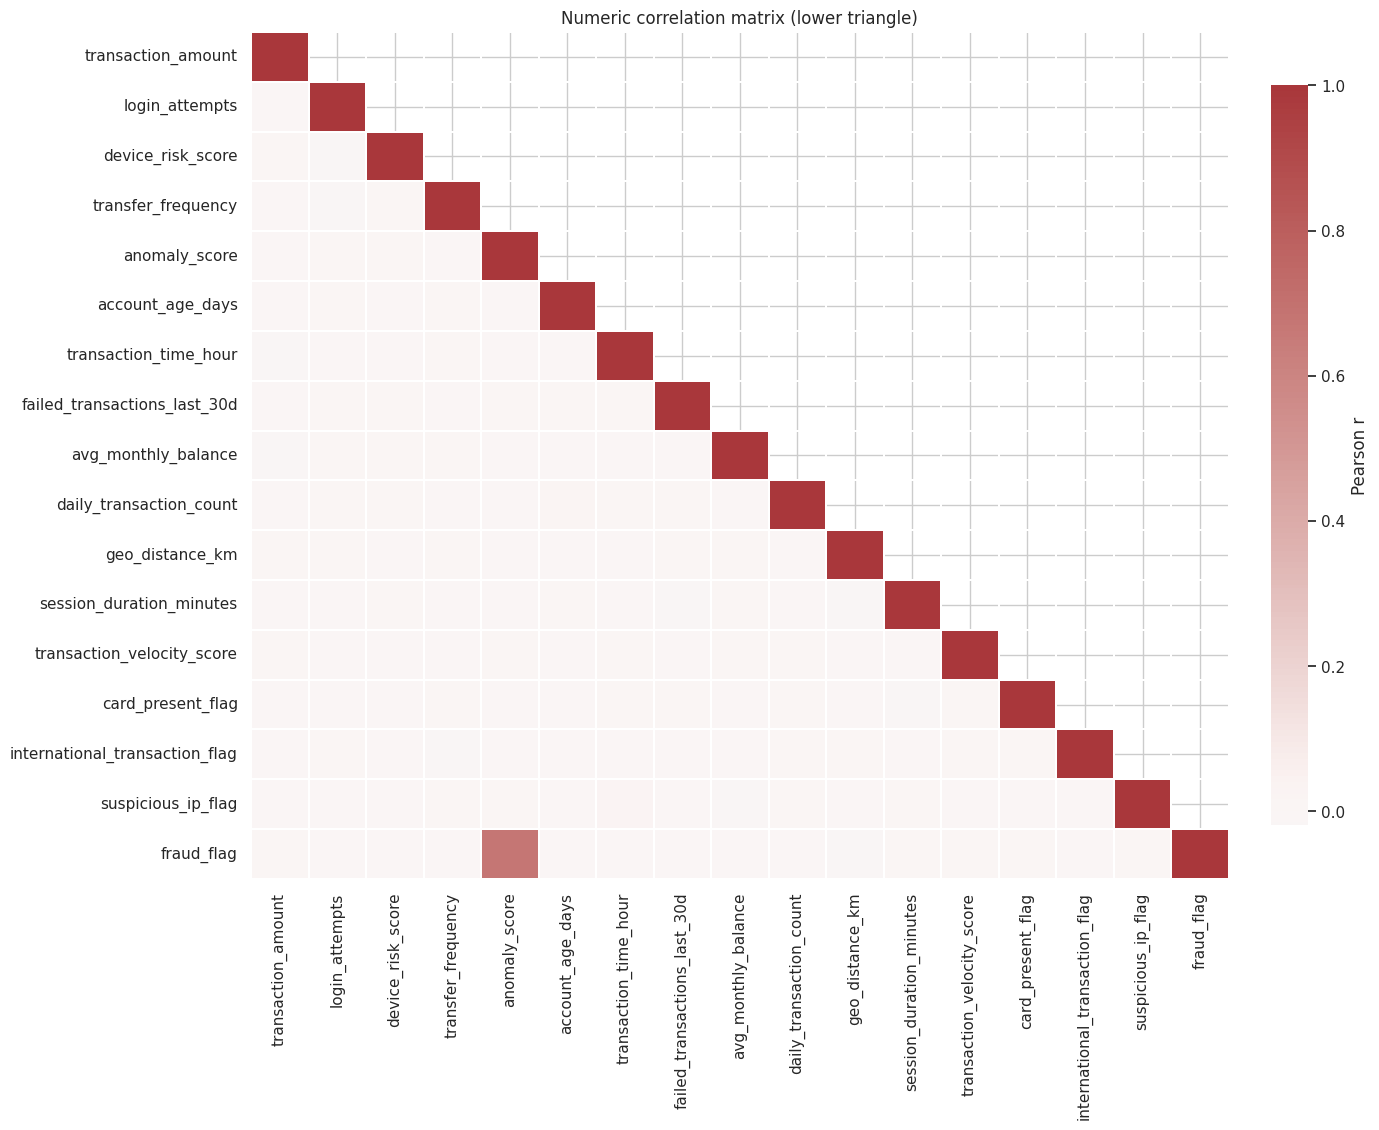

In [9]:
cm = corr_df[CORR_COLS].corr()
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm,
    mask=mask,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Pearson r", "fraction": 0.035, "pad": 0.04},
)
ax.set_title("Numeric correlation matrix (lower triangle)")
plt.subplots_adjust(right=0.88)
plt.show()


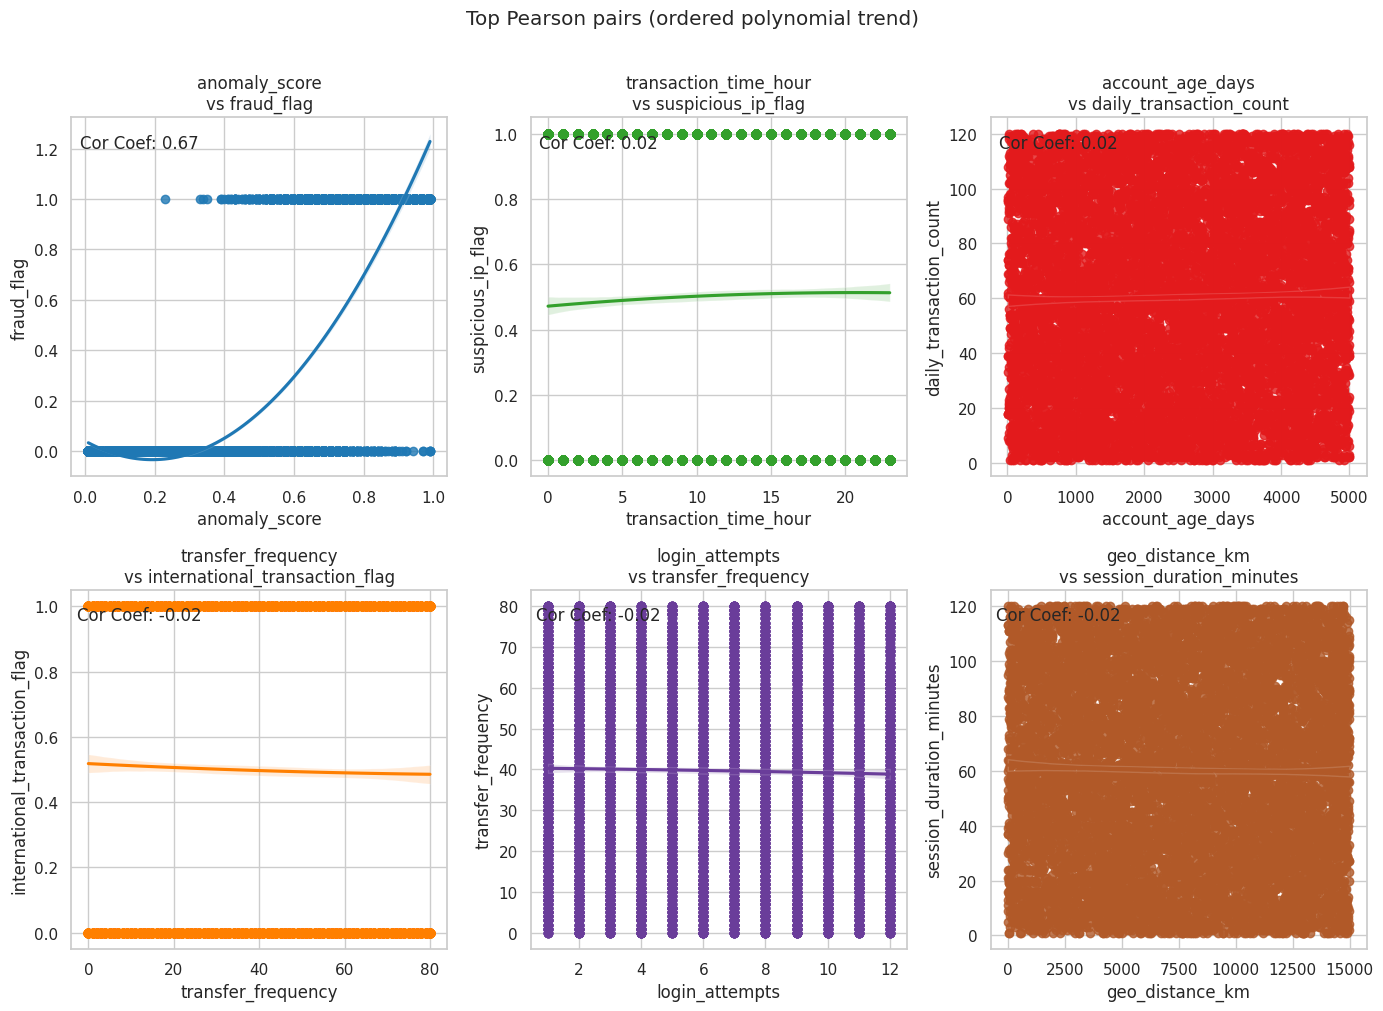

In [10]:
fig = corr_df.nica.rank_correlations_plots(
    CORR_COLS,
    n=6,
    columns=3,
    polyorder=2,
    figsize=(14, 10),
)
fig.suptitle("Top Pearson pairs (ordered polynomial trend)", y=1.01)
plt.tight_layout()
plt.show()


In [11]:
ct_fraud_channel = pd.crosstab(df["payment_channel"], df["fraud_flag"], normalize="index")
display(
    ct_fraud_channel.style.format("{:.3f}").background_gradient(cmap="Blues")
)


fraud_flag,False,True
payment_channel,,
ATM,0.870,0.130
Mobile App,0.872,0.128
POS Terminal,0.886,0.114
Web Banking,0.877,0.123


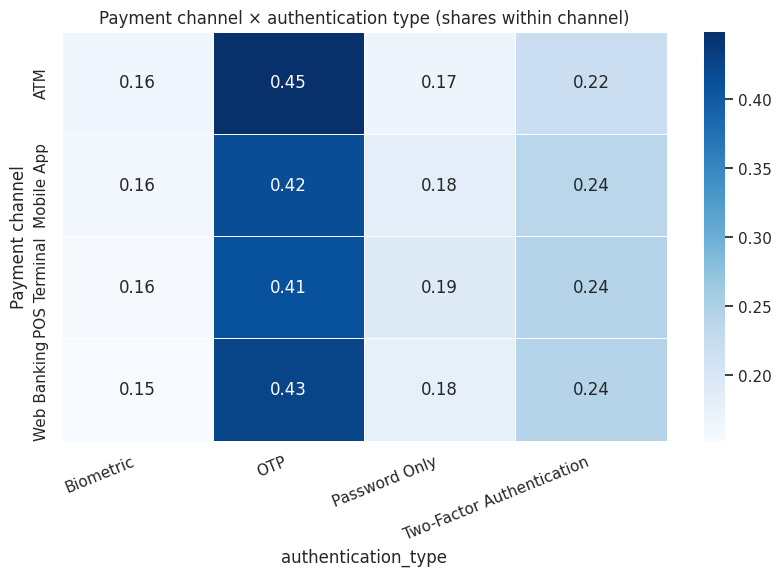

In [12]:
ct = pd.crosstab(df["payment_channel"], df["authentication_type"], normalize="index")
fig, ax = plt.subplots(figsize=(10.8, 6.2))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", linewidths=0.4, ax=ax)
ax.set_title("Payment channel × authentication type (shares within channel)")
ax.set_ylabel("Payment channel")
plt.xticks(rotation=22, ha="right")
plt.subplots_adjust(bottom=0.22, left=0.22, right=0.92)
plt.show()


/usr/local/lib/python3.12/dist-packages/nicaviz/dataframe_visualizer.py:396: FutureWarning: The provided callable <function mean at 0x7b1fa43991c0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = pd.pivot_table(


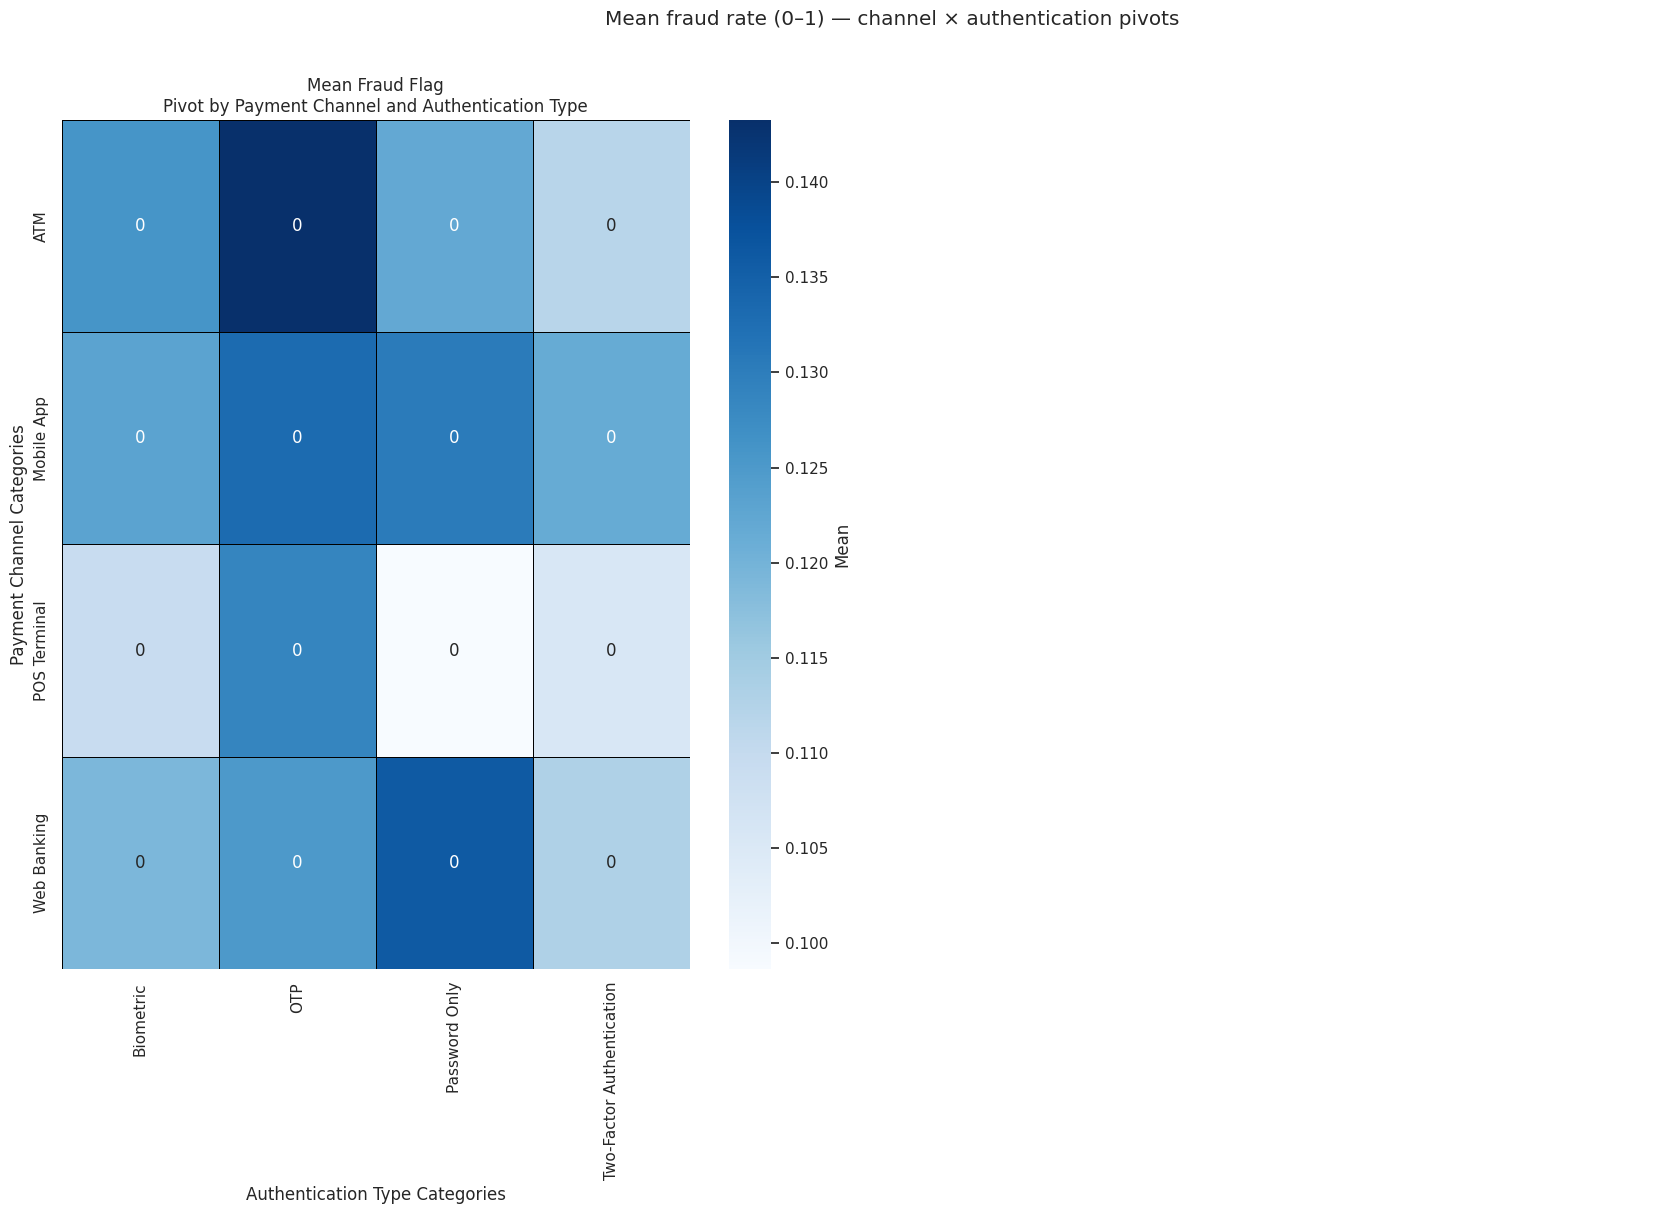

In [13]:
p_df = df[["payment_channel", "authentication_type", "fraud_flag"]].copy()
p_df["fraud_flag"] = p_df["fraud_flag"].astype(np.int8)
fig = p_df.nica.pivot_plots(
    ["payment_channel", "authentication_type"],
    "fraud_flag",
    np.mean,
    columns=2,
    figsize=(18, 12),
)
fig.suptitle("Mean fraud rate (0–1) — channel × authentication pivots", y=1.01)
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.show()


### Synthesis

**Distributions:** stratified box grids separate **fraud** and **non-fraud** mass across amount, session, velocity, and score fields—useful for spotting features whose scale shifts with the label before any classifier.

**Correlations:** the heatmap and **`nica.rank_correlations_plots`** highlight which engineered risk proxies move together; **`fraud_flag`** row/column shows linear associations with each numeric trait in this table only.

**Segments:** normalized **channel × authentication** shares and pivot means clarify where fraud concentrates relative to operational mix—compositional effects simple marginals can hide.
